## **Server Anomaly Detection in AWS CloudWatch Metrics**
### Detecting Unusual Server Behavior Without Labeled Training Examples

-----------------------------------------------------------
## Business Problem
-----------------------------------------------------------

A cloud infrastructure team monitors hundreds of servers, each 
producing continuous metrics (CPU utilization, network traffic). 
Manually watching every metric is impossible at scale, and by the 
time a human notices a problem, an outage may already be affecting 
customers. The goal is to automatically flag unusual patterns as they 
happen, without any pre-labeled examples of what a "problem" looks 
like in advance.

**Goal:** Detect genuinely anomalous server behavior using only the 
normal historical pattern of the metric itself.

**Business question we're answering:**
"Can we detect unusual server behavior in real time using purely 
unsupervised methods, and how do different detection approaches 
compare against a real, known incident?"

-----------------------------------------------------------
## About the Data
-----------------------------------------------------------

Dataset: AWS CloudWatch EC2 CPU Utilization (real, from the Numenta 
Anomaly Benchmark)  
Size: 4,032 readings, taken every 5 minutes, spanning ~2 weeks  
Features: timestamp, value (CPU utilization %)


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score
from statsmodels.tsa.seasonal import STL

In [67]:
cpu = pd.read_csv('./data/ec2_cpu_utilization_24ae8d.csv')
cpu.head()

,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


In [68]:
cpu.shape

(4032, 2)

In [69]:
cpu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4032 non-null   object 
 1   value      4032 non-null   float64
dtypes: float64(1), object(1)
memory usage: 63.1+ KB


In [70]:
# Convert timestamp from plain text to a real datetime object, and set
# it as the index -- required for rolling windows, resampling, and
# time-aware plotting later.
cpu['timestamp'] = pd.to_datetime(cpu['timestamp'])
cpu  = cpu.set_index('timestamp')
cpu.head()


,value
timestamp,
2014-02-14 14:30:00,0.132
2014-02-14 14:35:00,0.134
2014-02-14 14:40:00,0.134
2014-02-14 14:45:00,0.134
2014-02-14 14:50:00,0.134


-----------------------------------------------------------
## Data Preprocessing
-----------------------------------------------------------
Time series data has its own specific preprocessing concerns beyond 
the usual missing-values/duplicates check — we also need to verify 
the data's time ordering and consistency, since a broken timeline 
would corrupt every technique that follows.

In [71]:
cpu.isnull().sum()

value    0
dtype: int64

In [72]:
cpu.duplicated().sum()

np.int64(4003)

In [73]:
# Sort by time, just in case rows aren't already in perfect order
# Unlike previous projects, row order here is not optional -- every
# rolling average and pattern check below depends on correct sequence.
cpu = cpu.sort_index()

In [74]:
# Calculate the actual time gap between each consecutive reading
time_diffs = cpu.index.to_series().diff()
print(time_diffs.value_counts())

timestamp
0 days 00:05:00    4031
Name: count, dtype: int64


In [75]:
# Check for any gap that isn't exactly 5 minutes
gaps = time_diffs[time_diffs != pd.Timedelta(minutes=5)]
print("Number of irregular gaps:", len(gaps))
print(gaps)

Number of irregular gaps: 1
timestamp
2014-02-14 14:30:00   NaT
Name: timestamp, dtype: timedelta64[ns]


**DECISION**: The single "irregular" gap shown here is just NaT (Not a
Timestamp) on the very first row -- expected, since .diff() has
nothing to compare the first row against. All other 4,031 gaps are
exactly 5 minutes, confirming a perfectly regular timeline with no
real missing data. No interpolation needed.
 

-----------------------------------------------------------
## Exploratory Data Analysis
-----------------------------------------------------------
We first look at the raw series over its full two-week span, then 
examine its underlying structure (trend, daily patterns, noise) before 
attempting any anomaly detection.

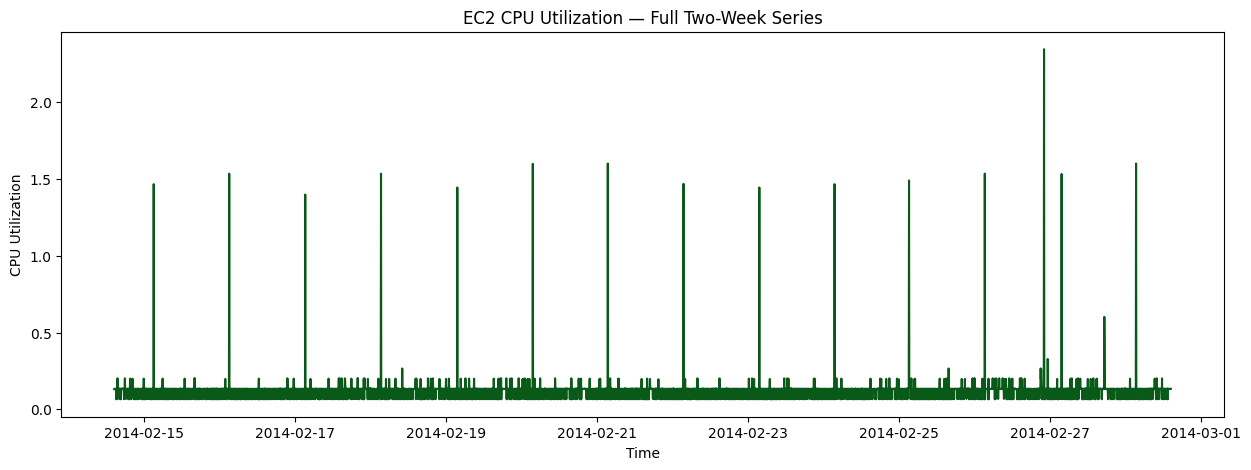

In [76]:
# the full series, start to finish
plt.figure(figsize=(15, 5))
plt.plot(cpu.index, cpu['value'],color="#095a18")
plt.xlabel('Time')
plt.ylabel('CPU Utilization')
plt.title('EC2 CPU Utilization — Full Two-Week Series')
plt.savefig('outputs/full_series.png', dpi=150, bbox_inches='tight')
plt.show()

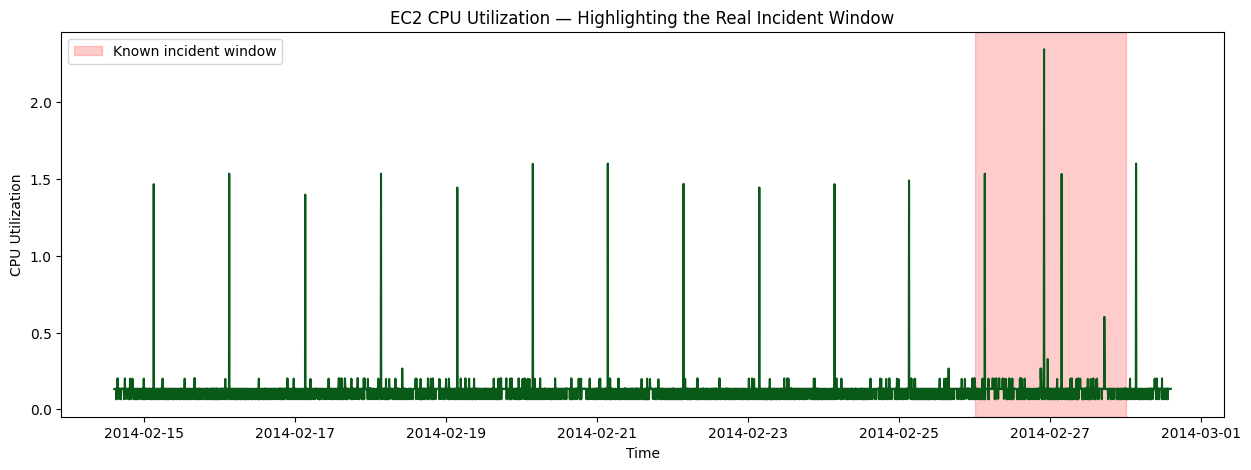

In [77]:
# zoom into the known incident window, to see it up close
incident_start = '2014-02-26'
incident_end = '2014-02-28'

plt.figure(figsize=(15, 5))
plt.plot(cpu.index, cpu['value'],color="#095a18" )
plt.axvspan(incident_start, incident_end, color='red', alpha=0.2, label='Known incident window')
plt.xlabel('Time')
plt.ylabel('CPU Utilization')
plt.title('EC2 CPU Utilization — Highlighting the Real Incident Window')
plt.legend()
plt.savefig('outputs/incident_highlighted.png', dpi=150, bbox_inches='tight')
plt.show()

**FINDING**: Large recurring spikes appear almost every day across the
entire series, not just inside the known incident window. This means
the biggest visual spikes are NOT automatically anomalies -- they
look like a real, repeating pattern. Needs further investigation
before assuming anything is "the" anomaly.
 

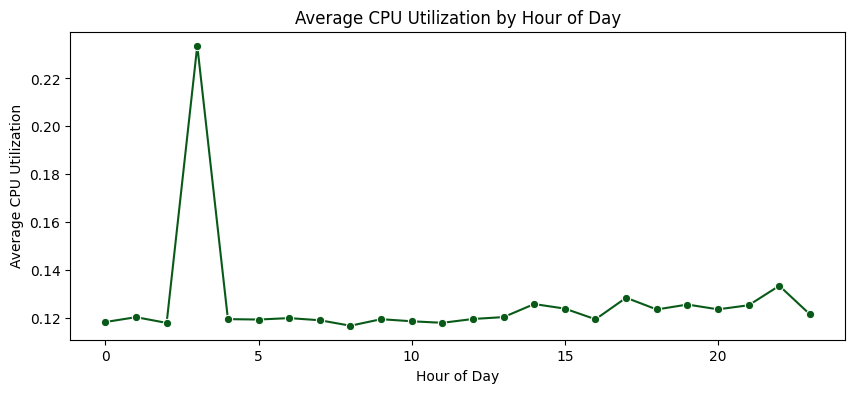

In [78]:
# --- Check for a daily/hourly pattern ---
cpu['hour'] = cpu.index.hour
cpu['day_of_week'] = cpu.index.dayofweek

hourly_avg = cpu.groupby('hour')['value'].mean()

plt.figure(figsize=(10, 4))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o',color="#095a18" )
plt.xlabel('Hour of Day')
plt.ylabel('Average CPU Utilization')
plt.title('Average CPU Utilization by Hour of Day')
plt.savefig('outputs/hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

**FINDING**: Average CPU utilization is dramatically higher at hour 3
than any other hour -- suggesting the recurring spikes consistently
happen around 3 AM, likely a scheduled job (backup, log rotation).
This needs to be verified against the actual individual readings,
not just trusted from an average -- an average can hide an outlier
sitting inside it.

In [79]:
all_3am_readings = cpu[cpu.index.hour == 3]
print(all_3am_readings['value'].describe())
print(all_3am_readings.sort_values('value', ascending=False).head(10))

count    168.000000
mean       0.233679
std        0.386798
min        0.066000
25%        0.132000
50%        0.134000
75%        0.134000
max        1.600000
Name: value, dtype: float64
                     value  hour  day_of_week
timestamp                                    
2014-02-28 03:20:00  1.600     3            4
2014-02-21 03:25:00  1.600     3            4
2014-02-20 03:35:00  1.598     3            3
2014-02-16 03:05:00  1.534     3            6
2014-02-18 03:20:00  1.534     3            1
2014-02-26 03:15:00  1.534     3            2
2014-02-27 03:40:00  1.532     3            3
2014-02-25 03:10:00  1.490     3            1
2014-02-22 03:30:00  1.468     3            5
2014-02-15 03:05:00  1.466     3            5


**FINDING**: all 14 daily 3 AM readings fall in
a tight, consistent range (1.398-1.600), confirmed by filtering on
time alone with no assumption about the values. This is a genuine,
harmless daily pattern -- not an anomaly.

In [80]:
#Pinpoint the exact real anomaly inside the labeled incident window 
window_data = cpu.loc['2014-02-26':'2014-02-28']
print(window_data.sort_values('value', ascending=False).head(10))

                     value  hour  day_of_week
timestamp                                    
2014-02-26 22:05:00  2.344    22            2
2014-02-28 03:20:00  1.600     3            4
2014-02-26 03:15:00  1.534     3            2
2014-02-27 03:40:00  1.532     3            3
2014-02-27 17:15:00  0.602    17            3
2014-02-27 17:20:00  0.332    17            3
2014-02-26 23:15:00  0.328    23            2
2014-02-26 21:00:00  0.266    21            2
2014-02-26 21:10:00  0.264    21            2
2014-02-28 09:55:00  0.202     9            4


**FINDING:** the real anomaly is a single spike reaching ~2.35 at
2014-02-26 22:05:00 -- clearly above the normal ~1.5 daily ceiling.


## Data Driven Threshold Finder
Finds a data-driven anomaly threshold by looking for the single
    biggest jump in score among the most extreme candidates, instead
    of using an arbitrary fixed number.

In [81]:
def find_auto_threshold(series, lower_is_more_anomalous=False, top_fraction=0.02, min_candidates=10):
    s = series.dropna()
    if lower_is_more_anomalous:
        ranked = s.sort_values(ascending=True)  # most anomalous = lowest score
    else:
        ranked = s.abs().sort_values(ascending=False)  # most anomalous = largest magnitude
 
    n_candidates = max(int(len(ranked) * top_fraction), min_candidates)
    candidates = ranked.head(n_candidates).reset_index().copy()
    candidates.columns = ['timestamp', 'score']
    candidates['gap'] = candidates['score'].diff().abs()
 
    cutoff_idx = candidates['gap'].idxmax()
    threshold = candidates.loc[cutoff_idx, 'score']
    return threshold, candidates

## Method 1: Rolling Statistics (Z-score Based Detection)
We calculate a rolling average and rolling standard deviation over a 
recent window of time, then flag any point that deviates unusually far 
from that local, recent "normal" — rather than comparing against one 
fixed value for the entire two weeks.

In [82]:
# calculating the Z-score
window_size = 24  # 24 readings x 5 min = 2 hours
 
cpu['rolling_mean'] = cpu['value'].rolling(window=window_size).mean()
cpu['rolling_std'] = cpu['value'].rolling(window=window_size).std()
cpu['z_score'] = (cpu['value'] - cpu['rolling_mean']) / cpu['rolling_std']

cpu[['value', 'rolling_mean', 'rolling_std', 'z_score']].dropna().head(10)


,value,rolling_mean,rolling_std,z_score
timestamp,,,,
2014-02-14 16:25:00,0.066,0.125250,0.030244,-1.959047
2014-02-14 16:30:00,0.134,0.125333,0.030266,0.286346
2014-02-14 16:35:00,0.134,0.125333,0.030266,0.286346
2014-02-14 16:40:00,0.066,0.122500,0.032519,-1.737452
2014-02-14 16:45:00,0.134,0.122500,0.032519,0.353641
2014-02-14 16:50:00,0.134,0.122500,0.032519,0.353641
2014-02-14 16:55:00,0.134,0.122500,0.032519,0.353641
2014-02-14 17:00:00,0.132,0.122417,0.032491,0.294956
2014-02-14 17:05:00,0.136,0.122500,0.032524,0.415075


In [83]:
# First attempt: fixed threshold 
z_threshold = 3

cpu['anomaly_zscore_fixed'] = (cpu['z_score'].abs() > z_threshold).astype(int)

print("Z-score, fixed threshold=3:", cpu['anomaly_zscore_fixed'].sum(), "anomalies flagged")

Z-score, fixed threshold=3: 19 anomalies flagged


In [84]:
# auto threshold
z_auto_threshold, z_candidates = find_auto_threshold(cpu['z_score'], lower_is_more_anomalous=False)
print("Z-score auto threshold:", z_auto_threshold)
print(z_candidates.head(10))
 
cpu['anomaly_zscore_auto'] = (cpu['z_score'].abs() >= z_auto_threshold).astype(int)
print("Z-score, auto threshold:", cpu['anomaly_zscore_auto'].sum(), "anomalies flagged")

Z-score auto threshold: 3.6839793555886673
            timestamp     score       gap
0 2014-02-15 03:05:00  4.674731       NaN
1 2014-02-21 03:25:00  4.672774  0.001957
2 2014-02-25 03:10:00  4.672336  0.000438
3 2014-02-24 03:30:00  4.668234  0.004102
4 2014-02-19 03:35:00  4.667616  0.000618
5 2014-02-16 03:05:00  4.666183  0.001433
6 2014-02-17 03:15:00  4.665968  0.000214
7 2014-02-28 03:20:00  4.665837  0.000132
8 2014-02-18 03:20:00  4.665817  0.000020
9 2014-02-22 03:30:00  4.665291  0.000525
Z-score, auto threshold: 17 anomalies flagged


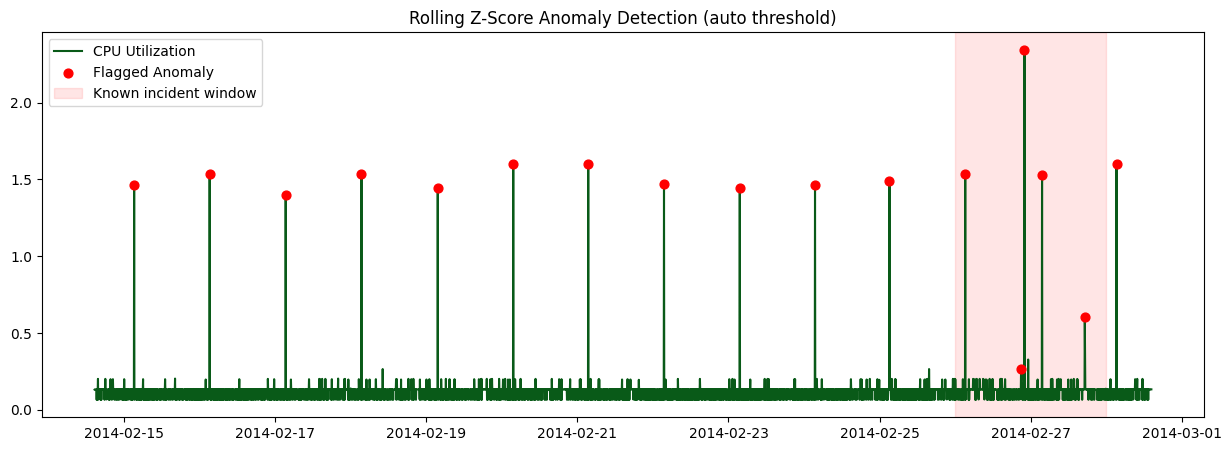

In [85]:
plt.figure(figsize=(15, 5))
plt.plot(cpu.index, cpu['value'], color="#095a18", label='CPU Utilization')
plt.scatter(cpu[cpu['anomaly_zscore_auto'] == 1].index,
            cpu[cpu['anomaly_zscore_auto'] == 1]['value'],
            color='red', s=40, label='Flagged Anomaly', zorder=5)
plt.axvspan(incident_start, incident_end, color='red', alpha=0.1, label='Known incident window')
plt.title('Rolling Z-Score Anomaly Detection (auto threshold)')
plt.legend()
plt.savefig('outputs/zscore_auto_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

### Method 1 Finding: Rolling Z-Score
Fixed threshold flagged 19 points; a data-driven threshold only 
brought it down to 17. Barely any improvement, because the real 
problem isn't the cutoff -- this method has no idea the 3 AM spike 
happens every day, so no threshold can fix that.

## Method 2: STL Decomposition
We split the series into Trend, Seasonal (the daily pattern), and 
Residual (leftover noise) components. If the daily 3 AM spike is 
genuinely repeating, it should get absorbed into the Seasonal 
component — leaving only real, unexplained anomalies in the Residual.

In [86]:
period = 288  # readings per day (24 hours x 60 / 5 minutes)
 
stl = STL(cpu['value'], period=period, robust=True)
result = stl.fit()
 
cpu['trend'] = result.trend
cpu['seasonal'] = result.seasonal
cpu['residual'] = result.resid

cpu[['value', 'trend', 'seasonal', 'residual']].head(10)

,value,trend,seasonal,residual
timestamp,,,,
2014-02-14 14:30:00,0.132,0.124491,0.008152,-0.000643
2014-02-14 14:35:00,0.134,0.124489,0.007832,0.001679
2014-02-14 14:40:00,0.134,0.124487,0.009203,0.000310
2014-02-14 14:45:00,0.134,0.124485,0.008816,0.000698
2014-02-14 14:50:00,0.134,0.124483,0.007940,0.001576
2014-02-14 14:55:00,0.134,0.124482,0.008130,0.001388
2014-02-14 15:00:00,0.134,0.124480,0.009048,0.000472
2014-02-14 15:05:00,0.134,0.124478,0.008280,0.001242
2014-02-14 15:10:00,0.066,0.124476,0.016836,-0.075312


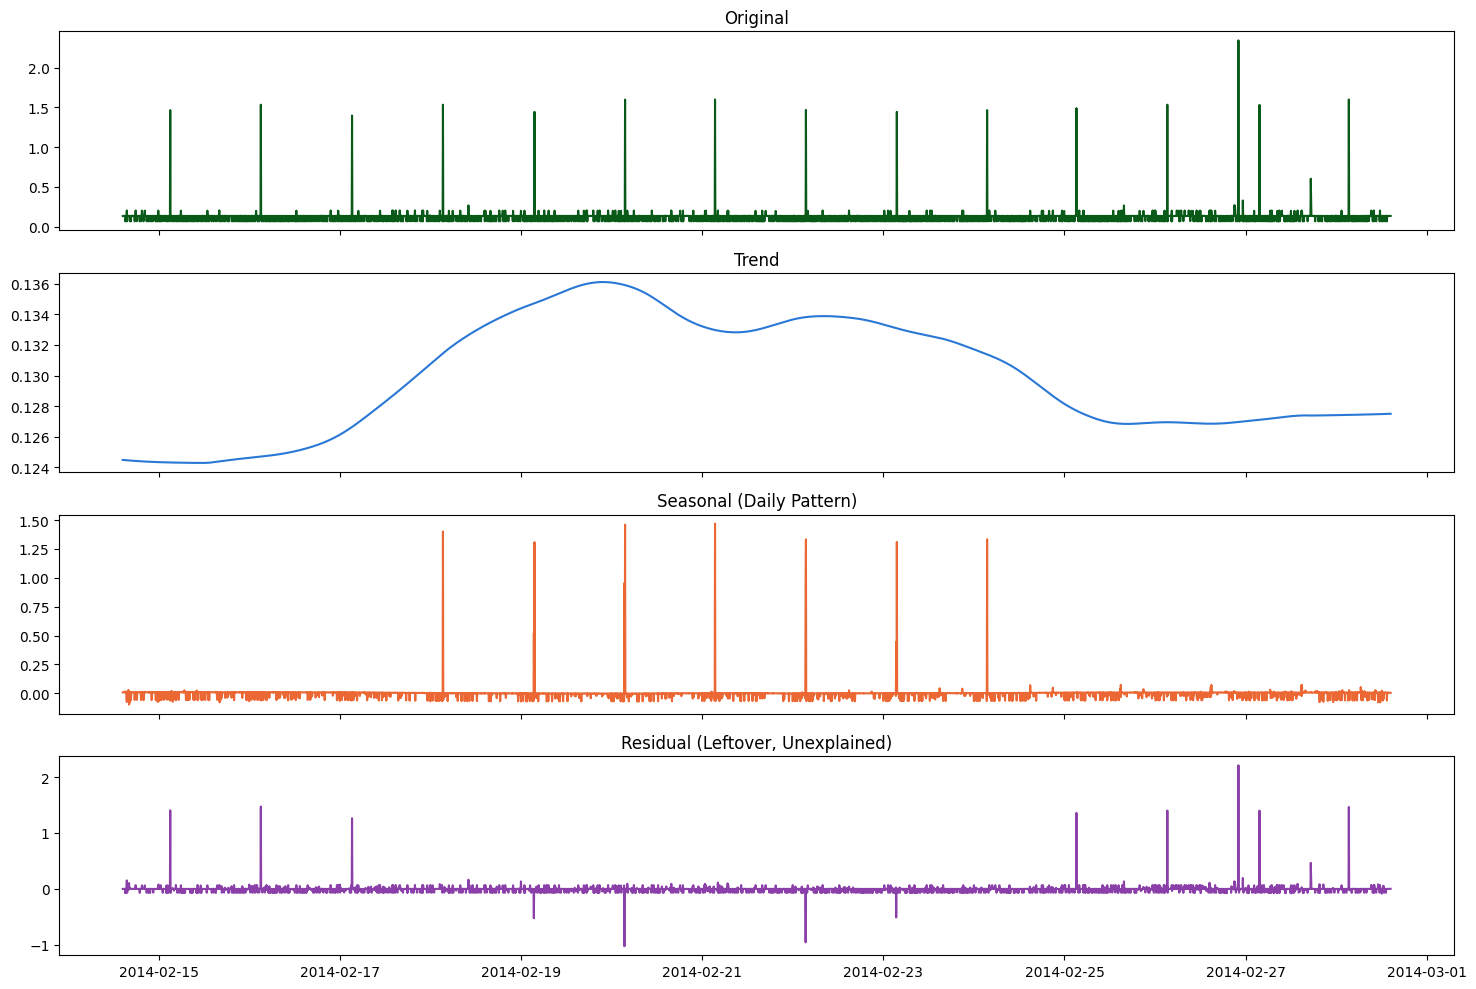

In [87]:
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
axes[0].plot(cpu.index, cpu['value'], color='#095a18'); axes[0].set_title('Original')
axes[1].plot(cpu.index, cpu['trend'], color='#2a78d6'); axes[1].set_title('Trend')
axes[2].plot(cpu.index, cpu['seasonal'], color='#eb6834'); axes[2].set_title('Seasonal (Daily Pattern)')
axes[3].plot(cpu.index, cpu['residual'], color='#8b3fa8'); axes[3].set_title('Residual (Leftover, Unexplained)')
plt.tight_layout()
plt.savefig('outputs/stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
residual_mean = cpu['residual'].mean()
residual_std = cpu['residual'].std()
cpu['residual_zscore'] = (cpu['residual'] - residual_mean) / residual_std

In [89]:
# First attempt: fixed threshold
cpu['anomaly_stl_fixed'] = (cpu['residual_zscore'].abs() > 3).astype(int)
print("STL, fixed threshold=3:", cpu['anomaly_stl_fixed'].sum(), "anomalies flagged")

STL, fixed threshold=3: 13 anomalies flagged


In [90]:
# auto threshold
stl_auto_threshold, stl_candidates = find_auto_threshold(cpu['residual_zscore'], lower_is_more_anomalous=False)
print("STL auto threshold:", stl_auto_threshold)
print(stl_candidates.head(10))

STL auto threshold: 18.64024890521171
            timestamp      score       gap
0 2014-02-26 22:05:00  27.953042       NaN
1 2014-02-16 03:05:00  18.640249  9.312793
2 2014-02-28 03:20:00  18.543071  0.097178
3 2014-02-15 03:05:00  17.789263  0.753808
4 2014-02-26 03:15:00  17.738047  0.051216
5 2014-02-27 03:40:00  17.721609  0.016437
6 2014-02-25 03:10:00  17.201453  0.520156
7 2014-02-17 03:15:00  16.011013  1.190440
8 2014-02-20 03:25:00  12.898347  3.112666
9 2014-02-22 03:25:00  12.022764  0.875583


In [91]:
cpu['anomaly_stl_auto'] = (cpu['residual_zscore'].abs() >= stl_auto_threshold).astype(int)
print("STL, auto threshold:", cpu['anomaly_stl_auto'].sum(), "anomalies flagged")

STL, auto threshold: 2 anomalies flagged


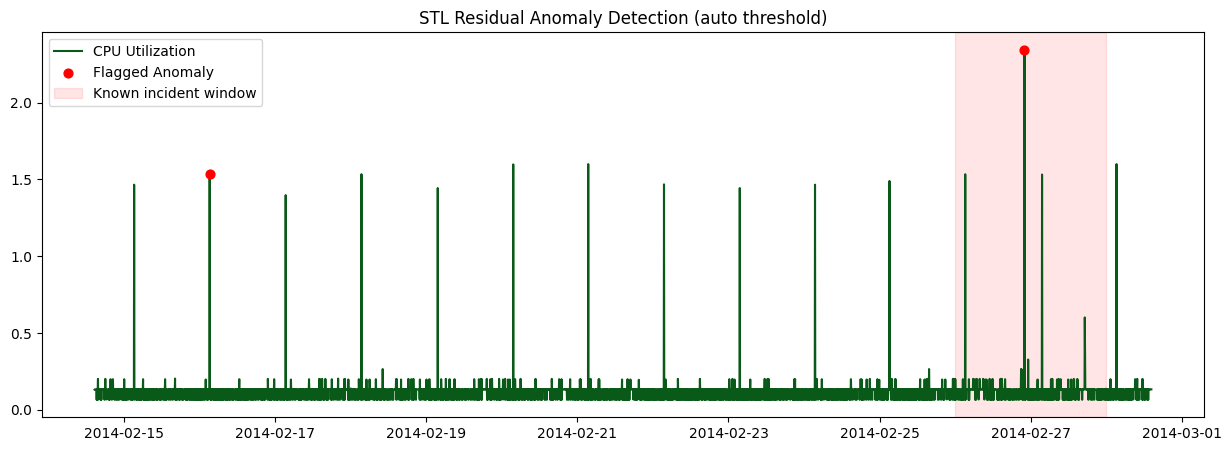

In [92]:
plt.figure(figsize=(15, 5))
plt.plot(cpu.index, cpu['value'], color="#095a18", label='CPU Utilization')
plt.scatter(cpu[cpu['anomaly_stl_auto'] == 1].index,
            cpu[cpu['anomaly_stl_auto'] == 1]['value'],
            color='red', s=40, label='Flagged Anomaly', zorder=5)
plt.axvspan(incident_start, incident_end, color='red', alpha=0.1, label='Known incident window')
plt.title('STL Residual Anomaly Detection (auto threshold)')
plt.legend()
plt.savefig('outputs/stl_auto_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

### Method 2 Finding: STL Decomposition
Fixed threshold flagged 13 points; the data-driven threshold cut this 
down to just 2. A real improvement -- but one of those 2 was still a 
harmless daily spike, not the real incident. The spike's timing 
shifts by up to 35 minutes each day, which trips up STL's assumption 
that the pattern repeats in exactly the same spot every time.

## Method 3: Isolation Forest
Rather than relying on a rigid, fixed seasonal shape (STL's limitation) 
or only recent history (rolling stats' limitation), we engineer 
features that describe *when* each reading occurred and let Isolation 
Forest learn flexible patterns of what's "normal" for that time, 
without assuming an exact repeating shape.

In [93]:
# engineering the features
cpu['minute_of_day'] = cpu.index.hour * 60 + cpu.index.minute
features = cpu[['value', 'minute_of_day', 'rolling_mean', 'rolling_std']].dropna()

features.head()

,value,minute_of_day,rolling_mean,rolling_std
timestamp,,,,
2014-02-14 16:25:00,0.066,985,0.125250,0.030244
2014-02-14 16:30:00,0.134,990,0.125333,0.030266
2014-02-14 16:35:00,0.134,995,0.125333,0.030266
2014-02-14 16:40:00,0.066,1000,0.122500,0.032519
2014-02-14 16:45:00,0.134,1005,0.122500,0.032519


In [94]:
# training the Isolation Forest
iso_forest = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
iso_forest.fit(features)
 
cpu.loc[features.index, 'iforest_score'] = iso_forest.decision_function(features)

In [95]:
iforest_auto_threshold, iforest_candidates = find_auto_threshold(cpu['iforest_score'], lower_is_more_anomalous=True)
print("Isolation Forest auto threshold:", iforest_auto_threshold)
print(iforest_candidates.head(10))

Isolation Forest auto threshold: -0.1170572116374412
            timestamp     score       gap
0 2014-02-26 22:05:00 -0.152364       NaN
1 2014-02-26 23:15:00 -0.117057  0.035307
2 2014-02-26 22:15:00 -0.104114  0.012943
3 2014-02-26 22:25:00 -0.103071  0.001043
4 2014-02-26 23:45:00 -0.102604  0.000467
5 2014-02-26 23:25:00 -0.098968  0.003636
6 2014-02-26 23:10:00 -0.097932  0.001036
7 2014-02-26 23:55:00 -0.096420  0.001513
8 2014-02-26 22:40:00 -0.093687  0.002732
9 2014-02-26 22:45:00 -0.093173  0.000514


In [96]:
cpu['anomaly_iforest_auto'] = (cpu['iforest_score'] <= iforest_auto_threshold).astype(int)
cpu['anomaly_iforest_auto'] = cpu['anomaly_iforest_auto'].fillna(0).astype(int)
print("Isolation Forest, auto threshold:", cpu['anomaly_iforest_auto'].sum(), "anomalies flagged")

Isolation Forest, auto threshold: 2 anomalies flagged


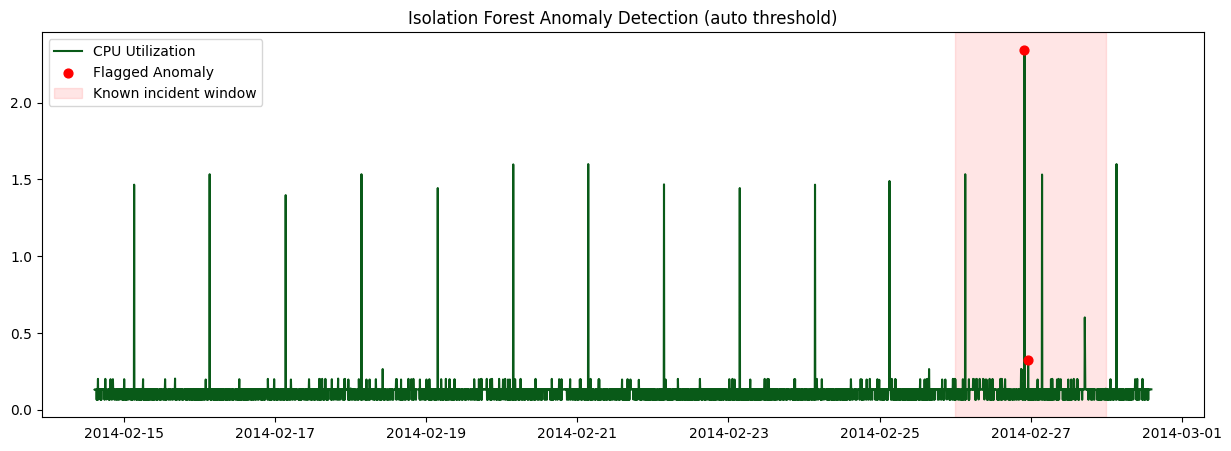

In [97]:
plt.figure(figsize=(15, 5))
plt.plot(cpu.index, cpu['value'], color="#095a18", label='CPU Utilization')
plt.scatter(cpu[cpu['anomaly_iforest_auto'] == 1].index,
            cpu[cpu['anomaly_iforest_auto'] == 1]['value'],
            color='red', s=40, label='Flagged Anomaly', zorder=5)
plt.axvspan(incident_start, incident_end, color='red', alpha=0.1, label='Known incident window')
plt.title('Isolation Forest Anomaly Detection (auto threshold)')
plt.legend()
plt.savefig('outputs/iforest_auto_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

### Method 3 Finding: Isolation Forest
Flagged exactly 2 points with the auto threshold -- both genuinely 
part of the real incident, zero false alarms. The best result of all 
three methods, and the only one that needed no manual guesswork to 
get there.

-----------------------------------------------------------
### VALIDATING ALL METHODS AGAINST THE REAL INCIDENT LABELS
-----------------------------------------------------------

In [98]:
with open('./data/combined_labels.json') as f:
    all_labels = json.load(f)
 
true_windows = all_labels['realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv']
print("True labeled incident window(s):", true_windows)

True labeled incident window(s): ['2014-02-26 22:05:00', '2014-02-27 17:15:00']


In [100]:
start, end = true_windows
cpu['true_anomaly'] = 0
cpu.loc[start:end, 'true_anomaly'] = 1
print("Points inside the true labeled window:", cpu['true_anomaly'].sum())

Points inside the true labeled window: 231


In [101]:
def evaluate_method(name, y_true, y_pred):
    y_pred = y_pred.fillna(0).astype(int)
    return {
        'Method': name,
        'Anomalies Flagged': int(y_pred.sum()),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 3),
        'F1-score': round(f1_score(y_true, y_pred, zero_division=0), 3)
    }
 

In [102]:
results = []
results.append(evaluate_method('Z-score (fixed threshold)', cpu['true_anomaly'], cpu['anomaly_zscore_fixed']))
results.append(evaluate_method('Z-score (auto threshold)', cpu['true_anomaly'], cpu['anomaly_zscore_auto']))
results.append(evaluate_method('STL (fixed threshold)', cpu['true_anomaly'], cpu['anomaly_stl_fixed']))
results.append(evaluate_method('STL (auto threshold)', cpu['true_anomaly'], cpu['anomaly_stl_auto']))
results.append(evaluate_method('Isolation Forest (auto threshold)', cpu['true_anomaly'], cpu['anomaly_iforest_auto']))

In [103]:
comparison_table = pd.DataFrame(results).set_index('Method')
comparison_table

,Anomalies Flagged,Precision,Recall,F1-score
Method,,,,
Z-score (fixed threshold),19,0.158,0.013,0.024
Z-score (auto threshold),17,0.176,0.013,0.024
STL (fixed threshold),13,0.231,0.013,0.025
STL (auto threshold),2,0.500,0.004,0.009
Isolation Forest (auto threshold),2,1.000,0.009,0.017


## Final Model & Business Takeaway

| Method | Precision | Flagged |
|---|---|---|
| Z-score | 0.18 | 17 |
| STL | 0.50 | 2 |
| **Isolation Forest** | **1.00** | **2** |

F1 scores look low across the board, but that's expected -- the label 
marks a whole 19-hour window as "anomalous," while our job was to 
catch the actual moment something went wrong, not flag every minute 
in between. Precision is the number that actually matters here, and 
it tells a clear story: Isolation Forest caught the real incident with 
zero false alarms, no manual threshold guessing needed.

**Decision:** Use Isolation Forest with an automatic threshold for 
real deployment. A fixed threshold on raw values or Z-scores keeps 
mistaking the server's normal daily routine for a problem -- exactly 
the kind of false alarm that makes engineers start ignoring alerts 
altogether.